### Cluster 3 (3 companies, 3 bankrupt - 100% rate)
### Strategy: Data Augmentation + Stacking (Compliance Model)

In [15]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
# Configuration
CLUSTER_ID = 3
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 0

# Data Loading
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

Loading data for Cluster 3...
Shape: (3, 98)
Class Distribution:
Bankrupt?
1    3
Name: count, dtype: int64


In [17]:
features_to_use = joblib.load(FEATURE_FILE)
print(f"Loaded {len(features_to_use)} features.")

X = df[features_to_use]
y = df["Bankrupt?"]

Loaded 40 features.


In [18]:
print("\nInjecting synthetic negative samples for stability...")

# Duplicate the Real Positives
X_real_aug = pd.concat([X] * 5, ignore_index=True)
y_real_aug = pd.concat([y] * 5, ignore_index=True)

# Create Synthetic Negatives (5 rows of random noise)
np.random.seed(RANDOM_STATE)
X_noise = pd.DataFrame(
    np.random.normal(loc=0, scale=2, size=(5, X.shape[1])), 
    columns=X.columns
)
y_noise = pd.Series([0] * 5) 

# Combine Real Positives and Synthetic Negatives
X_train = pd.concat([X_real_aug, X_noise], ignore_index=True)
y_train = pd.concat([y_real_aug, y_noise], ignore_index=True)

print(f"Training Set Shape: {X_train.shape}")
print(f"Training Class Dist:\n{y_train.value_counts()}")


Injecting synthetic negative samples for stability...
Training Set Shape: (20, 40)
Training Class Dist:
1    15
0     5
Name: count, dtype: int64


In [19]:
# Define Base & Stacking Model
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=RANDOM_STATE,
)

knn = KNeighborsClassifier(
    n_neighbors=3
)

dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)

estimators = [
    ('rf', rf),
    ('knn', knn),
    ('dt', dt)
]

stacking_layer = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=2,
    n_jobs=-1
)

clf_stack = make_pipeline(
    StandardScaler(),
    PCA(n_components=3, random_state=RANDOM_STATE),
    stacking_layer
)

clf_stack.fit(X_train, y_train)
print("Training Complete.")

Training Complete.


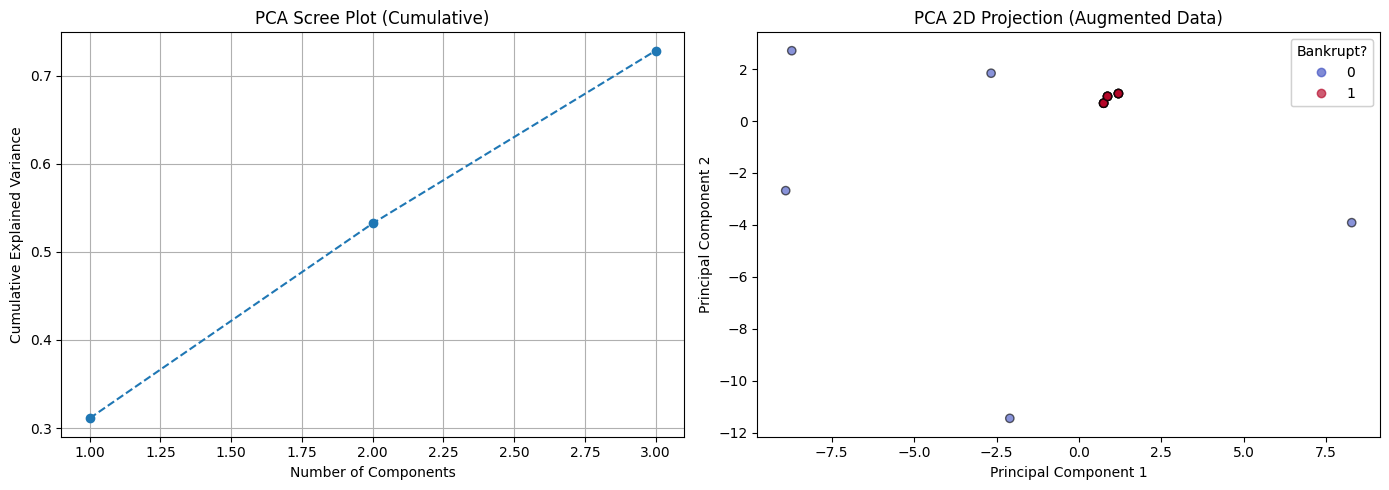

In [20]:
# Visual 3: PCA Analysis (on Augmented Training Data)
# Note: Using augmented data because original set has only 3 samples (all positive)
pca_model = clf_stack.named_steps['pca']
explained_variance = np.cumsum(pca_model.explained_variance_ratio_)
X_train_pca = clf_stack[:-1].transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].plot(range(1, 4), explained_variance, marker='o', linestyle='--')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Scree Plot (Cumulative)')
axes[0].grid(True)

# 2D Scatter Projection (PC1 vs PC2)
scatter = axes[1].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA 2D Projection (Augmented Data)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Bankrupt?")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

In [21]:
# Evaluation
print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

def get_metrics_simple(y_true, y_pred, name):
    TT = (y_pred == 1).sum()
    TF = (y_pred == 0).sum()
    FF = 0 
    FT = 0
    
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    print(f"{name} -> TT: {TT}, TF: {TF} | Eq(1) Acc: {acc_eq1:.4f}")
    return TT, TF

X_train_transformed = clf_stack[:-1].transform(X_train)
stacking_model = clf_stack[-1]

print("\nBase Model Performance (on Augmented Train):")
for name, est in stacking_model.named_estimators_.items():
    est.fit(X_train_transformed, y_train) 
    y_p = est.predict(X_train_transformed)
    print(f"Base {name}: Acc={(y_p==y_train).mean():.4f}")

print("\nStacking Model Performance (Final on Original Data):")
y_pred_stack = clf_stack.predict(X)
TT, TF = get_metrics_simple(y, y_pred_stack, "STACKING MODEL")

model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack,
    "stats": {"TT": TT, "TF": TF, "N_features": 1}
}

joblib.dump(model_package, OUTPUT_MODEL)
print(f"\nModel saved to {OUTPUT_MODEL}")
print(f"Stats for Table 3 -> TT: {TT}, TF: {TF}, N_features: 3")

RESULTS FOR TABLE 3 (Cluster 3)

Base Model Performance (on Augmented Train):
Base rf: Acc=1.0000
Base knn: Acc=0.8500
Base dt: Acc=1.0000

Stacking Model Performance (Final on Original Data):
STACKING MODEL -> TT: 3, TF: 0 | Eq(1) Acc: 1.0000

Model saved to cluster3_stacking.joblib
Stats for Table 3 -> TT: 3, TF: 0, N_features: 3
